<a href="https://colab.research.google.com/github/Joel-Wang-Math/MIDAS-AI-for-Engineers/blob/main/Copy_of_day03_petfinder_model_evaluation_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Evaluation with PetFinder Adoption Data

**Student Version**

**Shanshan (Shirley) Liu, Ph.D.**

**Summer Academy Afternoon Session, Part 1**  
**Time:** 2:00–3:30 PM  
**Main question:** *Can we predict whether a pet will be adopted within the first week?*

This notebook uses the PetFinder Adoption Prediction dataset as a classification example for model evaluation. The original Kaggle task predicts `AdoptionSpeed` with five categories. In this class, we simplify the task into a binary classification problem so that we can focus deeply on accuracy, confusion matrices, precision, recall, and F1 score.

---

## Part 1 plan

1. Load and inspect the PetFinder dataset  
2. Define a prediction target: `FastAdoption`  
3. Explore target and feature distributions  
4. Build a preprocessing pipeline  
5. Train a first classifier  
6. Evaluate with accuracy, confusion matrix, precision, recall, and F1 score  

---


## 1. Import modules

We import everything the notebook needs up front. Don't worry about what each tool does yet; we introduce each one where we first use it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)

## 2. Load the PetFinder dataset

This notebook uses the PetFinder Adoption Prediction dataset from Kaggle:

https://www.kaggle.com/competitions/petfinder-adoption-prediction

The next cell loads the data directly from the course GitHub repository; there is nothing to download.


In [2]:
url = "https://raw.githubusercontent.com/elleobrien/MIDAS_summer_academy_student/main/day03/petfinder.csv"
raw_df = pd.read_csv(url)
raw_df.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


## 3. Inspect the dataset

## Dataset columns

The PetFinder dataset contains one row for each pet adoption profile. Some columns are numerical, while many columns are categorical variables represented by integer codes.

Full field definitions are on the Kaggle data page: [Kaggle PetFinder Adoption Prediction · Data](https://www.kaggle.com/competitions/petfinder-adoption-prediction/data).

### Pet identity and profile information

| Column | Meaning |
| --- | --- |
| `PetID` | Unique ID of the pet profile |
| `Name` | Name of the pet. Empty if the pet is not named |
| `Description` | Text description written for the pet profile. Most descriptions are in English, but some may be in Malay or Chinese |
| `RescuerID` | Unique ID of the rescuer or organization posting the profile |

### Pet characteristics

| Column | Meaning |
| --- | --- |
| `Type` | Type of animal: `1` = Dog, `2` = Cat |
| `Age` | Age of the pet when listed, **in months** |
| `Breed1` | Primary breed of the pet (refers to the breed-label dictionary) |
| `Breed2` | Secondary breed, if the pet is a mixed breed |
| `Gender` | `1` = Male, `2` = Female, `3` = Mixed (when the profile represents a group of pets) |
| `Color1` | Primary color of the pet |
| `Color2` | Secondary color of the pet |
| `Color3` | Third color of the pet |
| `MaturitySize` | Size at maturity: `0` = Not Specified, `1` = Small, `2` = Medium, `3` = Large, `4` = Extra Large |
| `FurLength` | `0` = Not Specified, `1` = Short, `2` = Medium, `3` = Long |
| `Health` | `0` = Not Specified, `1` = Healthy, `2` = Minor Injury, `3` = Serious Injury |

### Care and adoption information

| Column | Meaning |
| --- | --- |
| `Vaccinated` | `1` = Yes, `2` = No, `3` = Not Sure |
| `Dewormed` | `1` = Yes, `2` = No, `3` = Not Sure |
| `Sterilized` | Spayed / neutered: `1` = Yes, `2` = No, `3` = Not Sure |
| `Quantity` | Number of pets represented in the profile |
| `Fee` | Adoption fee in MYR (Malaysian Ringgit). `0` = free |
| `State` | State location in Malaysia (refers to the state-label dictionary) |
| `VideoAmt` | Number of videos uploaded for this profile |
| `PhotoAmt` | Number of photos uploaded for this profile |




> When looking at the first few rows, pay attention to two things:

1. Which columns are true numerical features, such as `Age`, `Fee`, `PhotoAmt`, and `VideoAmt`?
2. Which columns are categorical codes, such as `Type`, `Gender`, `Vaccinated`, and `State`?

This distinction matters because different types of features require different preprocessing steps.



In [3]:
print("Dataset shape:", raw_df.shape)
print("\nColumn names:")
print(raw_df.columns.tolist())

raw_df.head()

Dataset shape: (14993, 24)

Column names:
['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID', 'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed']


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


## 4. Understand the original target

The original target is `AdoptionSpeed`. Smaller values mean faster adoption. For this class, we will simplify the task into a binary classification problem later.

### Target variable

- `AdoptionSpeed`: The adoption speed category. **Lower values mean faster adoption**. This is the original prediction target in the Kaggle competition.


In [19]:
counts = raw_df["AdoptionSpeed"].value_counts().sort_index()
percentages = raw_df["AdoptionSpeed"].value_counts(normalize=True).sort_index() * 100

adoption_distribution = pd.DataFrame({
    "count": counts,
    "percentage": percentages.round(2)
})

adoption_distribution

,count,percentage
AdoptionSpeed,,
0,410,2.73
1,3090,20.61
2,4037,26.93
3,3259,21.74
4,4197,27.99


In [20]:
display(counts)

,count
AdoptionSpeed,
0,410
1,3090
2,4037
3,3259
4,4197


## 5. Create a binary classification target

We define `FastAdoption = 1` if the pet was adopted on the same day or within the first week. Otherwise, `FastAdoption = 0`.

In [21]:
df = raw_df.copy()

# FastAdoption = 1 means adopted on the same day or within the first week.
# FastAdoption = 0 means adopted later than the first week, or not adopted after 100 days.
df["FastAdoption"] = (df["AdoptionSpeed"] <= 1).astype(int)

df[["AdoptionSpeed", "FastAdoption"]].head(10)

,AdoptionSpeed,FastAdoption
0,2,0
1,0,1
2,3,0
3,2,0
4,2,0
5,2,0
6,1,1
7,3,0
8,1,1
9,4,0


In [24]:
df = raw_df.copy()

# FastAdoption = 1 means adopted on the same day or within the first week.
# FastAdoption = 0 means adopted later than the first week, or not adopted after 100 days.
df["FastAdoption"] = (df["AdoptionSpeed"] <= 1).astype(int) # .astype(int) converts the boolean (True/False) result into integers (1/0).

df[["AdoptionSpeed", "FastAdoption"]].head(10)

,AdoptionSpeed,FastAdoption
0,2,0
1,0,1
2,3,0
3,2,0
4,2,0
5,2,0
6,1,1
7,3,0
8,1,1
9,4,0


In [25]:
fast_counts = df["FastAdoption"].value_counts().sort_index()
fast_percentages = df["FastAdoption"].value_counts(normalize=True).sort_index() * 100

fast_distribution = pd.DataFrame({
    "count": fast_counts,
    "percentage": fast_percentages.round(2)
})

fast_distribution.index = ["Slow adoption", "Fast adoption"]
fast_distribution

,count,percentage
Slow adoption,11493,76.66
Fast adoption,3500,23.34


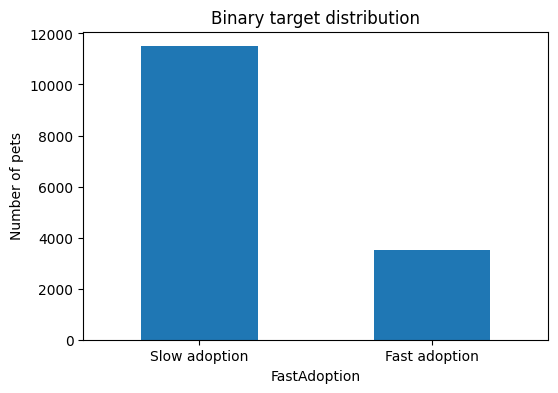

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
df["FastAdoption"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xticklabels(["Slow adoption", "Fast adoption"], rotation=0)
ax.set_ylabel("Number of pets")
ax.set_title("Binary target distribution")
plt.show()

## 6. Quick exploratory data analysis

Before training a machine learning model, we first explore the data to understand the prediction problem.

In this section, we ask a few simple questions:

1. Are dogs and cats adopted at different speeds?
2. Are younger pets adopted faster than older pets?
3. Do profiles with more photos tend to have faster adoption?
4. Does adoption fee appear to be related to adoption speed?

These exploratory checks help us decide which features may be useful for modeling.

One caution applies to everything in this section: these patterns are **associations, not causal effects**. If pets with more photos are adopted faster, that does not mean uploading more photos *causes* faster adoption. Other factors such as age, breed, health, location, or rescuer quality may drive both. The goal here is to build intuition about the dataset before fitting models, not to prove causation.

In [28]:
# Helpful labels for a few encoded categorical variables.
type_map = {1: "Dog", 2: "Cat"}
gender_map = {1: "Male", 2: "Female", 3: "Mixed"}
maturity_size_map = {1: "Small", 2: "Medium", 3: "Large", 4: "Extra Large"}
fur_length_map = {1: "Short", 2: "Medium", 3: "Long"}
vaccinated_map = {1: "Yes", 2: "No", 3: "Not Sure"}

df["TypeLabel"] = df["Type"].map(type_map)
df["GenderLabel"] = df["Gender"].map(gender_map)
df["MaturitySizeLabel"] = df["MaturitySize"].map(maturity_size_map)
df["FurLengthLabel"] = df["FurLength"].map(fur_length_map)
df["VaccinatedLabel"] = df["Vaccinated"].map(vaccinated_map)

### 6.1 Dogs vs. cats

First, we compare the proportion of fast adoption between dogs and cats.

In [29]:
pd.crosstab(
    df["TypeLabel"],
    df["FastAdoption"],
    normalize="index"
).rename(columns={0: "Slow adoption", 1: "Fast adoption"}).round(3)

FastAdoption,Slow adoption,Fast adoption
TypeLabel,,
Cat,0.724,0.276
Dog,0.803,0.197


In this dataset, cats appear to have a higher fast-adoption rate than dogs. As noted above, this is an association only: age, breed, health, photos, and fee also differ between cats and dogs.

### 6.2 Gender and adoption speed

We can also compare adoption outcomes across gender categories.

In this dataset:

- `Male` means the profile is for a male pet.
- `Female` means the profile is for a female pet.
- `Mixed` means the profile represents a group of pets with mixed genders.

The table below shows the proportion of slow and fast adoption within each gender category.

In [30]:
pd.crosstab(
    df["GenderLabel"],
    df["FastAdoption"],
    normalize="index"
).rename(columns={0: "Slow adoption", 1: "Fast adoption"}).round(3)

FastAdoption,Slow adoption,Fast adoption
GenderLabel,,
Female,0.784,0.216
Male,0.739,0.261
Mixed,0.777,0.223


This table helps us check whether adoption outcomes differ across male, female, and mixed-gender profiles.

Remember that `Mixed` usually means the listing represents a group of pets, not a single pet. Differences for the `Mixed` category may therefore reflect group listings rather than gender itself.

In [11]:
pd.crosstab(
    [df["TypeLabel"], df["GenderLabel"]],
    df["FastAdoption"],
    normalize="index"
).rename(columns={0: "Slow adoption", 1: "Fast adoption"}).round(3)

FastAdoption           Slow adoption  Fast adoption
TypeLabel GenderLabel                              
Cat       Female               0.731          0.269
          Male                 0.711          0.289
          Mixed                0.732          0.268
Dog       Female               0.822          0.178
          Male                 0.763          0.237
          Mixed                0.843          0.157

📝 **Practice: Compare another categorical feature**

Choose another categorical feature and compare its fast-adoption rate. `MaturitySizeLabel` is a useful example because it describes pet size.

Which category appears to have the highest fast-adoption rate? What should we be careful about before treating this as a causal explanation?

In [12]:
# TODO: Write your categorical-feature comparison here.
# Hint: use pd.crosstab(..., normalize="index")

### 6.3 Numerical features by adoption outcome

Next, we compare several numerical features between slow-adopted and fast-adopted pets.

The table below shows the **average value** of each feature for the two adoption groups.

- `Age`: pet age in months
- `Fee`: adoption fee
- `PhotoAmt`: number of uploaded photos
- `VideoAmt`: number of uploaded videos

This helps us see whether fast-adopted pets look different from slow-adopted pets on average.

In [31]:
summary_by_target = df.groupby("FastAdoption")[["Age", "Fee", "PhotoAmt", "VideoAmt"]].mean()
summary_by_target.index = ["Slow adoption", "Fast adoption"]
summary_by_target.round(2)

,Age,Fee,PhotoAmt,VideoAmt
Slow adoption,10.98,21.08,3.95,0.06
Fast adoption,8.72,21.85,3.68,0.05


From this table, we can make a few observations:

- Fast-adopted pets are younger on average: about **8.72 months**, compared with **10.98 months** for slow-adopted pets.
- The average adoption fee is very similar between the two groups: about **21–22**.
- Slow-adopted pets have slightly more uploaded photos on average: **3.95** compared with **3.68**.
- Videos are rare in both groups, with average values close to zero.

These differences are relatively small, especially for fee, photos, and videos. Age shows a clearer difference, but we should still be careful: this table only compares simple averages and does not control for other features.

📝 **Practice: Mean vs. median for numerical features**

The previous table used means. Recompute the same summary using medians, then compare the result.

Which features change the most when we use the median instead of the mean? What does that suggest about skew or outliers?

In [32]:
# TODO: Write your median summary here.

## 7. Select features for modeling

Now we choose which columns will be used as input features for the machine learning models.

In supervised learning, we usually separate the data into:

- `X`: the input features used to make predictions
- `y`: the target variable we want to predict

In this notebook, our target variable is:

- `FastAdoption`: whether a pet was adopted within the first week

We use a manageable set of tabular features so that we can focus on model evaluation and model selection, rather than text processing, image processing, or advanced feature engineering.

We divide the input features into two groups:

- **Numerical features**: `Age`, `Quantity`, `Fee`, `VideoAmt`, `PhotoAmt`
- **Categorical features**: `Type`, `Gender`, `MaturitySize`, `FurLength`, `Vaccinated`, `Dewormed`, `Sterilized`, `Health`, `Breed1`, `Color1`, `State`

Many categorical features are stored as numbers, but they are not continuous numerical values. For example, `Type = 1` means dog and `Type = 2` means cat. These values are category labels, not quantities. We will handle them as categorical features using one-hot encoding later.


In [33]:
# We use tabular features only in this class.
# We intentionally exclude Description, Name, PetID, RescuerID, and image features.

numeric_features = [
    "Age", "Quantity", "Fee", "VideoAmt", "PhotoAmt"
]

categorical_features = [
    "Type", "Gender", "MaturitySize", "FurLength",
    "Vaccinated", "Dewormed", "Sterilized", "Health",
    "Breed1", "Color1", "State"
]

target = "FastAdoption"

model_df = df[numeric_features + categorical_features + [target]].copy()

X = model_df.drop(columns=[target])
y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (14993, 16)
y shape: (14993,)


> **What do the shapes mean?**
>
> We have **14,993 pet profiles**, each described by **16 input features** (`X`) and one target value (`y`, `FastAdoption`).

> **Discussion: Why do we exclude some columns?**
---


## 8. Train/test split

Before training a model, we split the dataset into two parts:

- **Training set**: used to train the model
- **Test set**: held out and used only for final evaluation

This is important because we want to evaluate how well the model performs on new, unseen data. If we evaluate the model on the same data used for training, the performance may look too optimistic.

In this notebook, we use 80% of the data for training and 20% for testing.

**Note:**
The test set will be held out until final evaluation. Model comparison and hyperparameter tuning should use the training set only.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,   # what is this for?
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (11994, 16)
Test set: (2999, 16)


In [35]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training target distribution:
FastAdoption
0    0.767
1    0.233
Name: proportion, dtype: float64

Test target distribution:
FastAdoption
0    0.767
1    0.233
Name: proportion, dtype: float64



> Why do we check the target distribution?




Our target variable is not perfectly balanced:

- About **76.7%** of pets are slow adoption
- About **23.3%** of pets are fast adoption

Because of this, we use `stratify=y` when splitting the data.

This makes sure that the training set and test set have similar proportions of slow-adoption and fast-adoption pets.

In our result:

- Training set: 76.7% slow adoption, 23.3% fast adoption
- Test set: 76.7% slow adoption, 23.3% fast adoption

This is good because the test set still represents the original prediction problem.

<details>
<summary><b>Discussion question</b> (optional — click to expand)</summary>

What might go wrong if the test set accidentally contained very few fast-adoption pets?

</details>

## 9. Check for missing values before preprocessing

Before building the preprocessing pipeline, we should check whether the selected modeling features contain missing values.

This matters because many scikit-learn models, including Logistic Regression, KNN, MLPClassifier, and many tree-based models, do not accept `NaN` values directly. If missing values are present, the model may fail before it ever starts learning.

Even if this selected feature set has few or no missing values today, including imputation in the pipeline is still a good habit. The imputer is fit only on the training data inside the pipeline, which helps avoid data leakage from the test set.


In [36]:
missing_summary = pd.DataFrame({
    "train_missing_count": X_train.isna().sum(),
    "train_missing_percent": (X_train.isna().mean() * 100).round(2),
    "test_missing_count": X_test.isna().sum(),
    "test_missing_percent": (X_test.isna().mean() * 100).round(2),
}).sort_values("train_missing_count", ascending=False)

print("Total missing values in selected training features:", int(X_train.isna().sum().sum()))
missing_summary


Total missing values in selected training features: 0


,train_missing_count,train_missing_percent,test_missing_count,test_missing_percent
Age,0,0.0,0,0.0
Quantity,0,0.0,0,0.0
Fee,0,0.0,0,0.0
VideoAmt,0,0.0,0,0.0
PhotoAmt,0,0.0,0,0.0
Type,0,0.0,0,0.0
Gender,0,0.0,0,0.0
MaturitySize,0,0.0,0,0.0
FurLength,0,0.0,0,0.0
Vaccinated,0,0.0,0,0.0


## 10. Build a preprocessing pipeline

Before training machine learning models, we need to convert the raw data into a format that the models can use.

In this dataset, we have two types of input features:

1. **Numerical features**, such as `Age`, `Fee`, `PhotoAmt`, and `VideoAmt`
2. **Categorical features**, such as `Type`, `Gender`, `Vaccinated`, `Health`, and `State`

These two types of features need different preprocessing steps.

### Numerical features

For numerical features, we use two steps:

- `SimpleImputer(strategy="median")`: fills missing numerical values using the median value of that column.
- `StandardScaler()`: standardizes numerical features so they have a similar scale.

Scaling is useful for models such as Logistic Regression, KNN, and MLPClassifier because these models can be sensitive to feature scale.

### Categorical features

For categorical features, we also use two steps:

- `SimpleImputer(strategy="most_frequent")`: fills missing categorical values using the most common category.
- `OneHotEncoder(handle_unknown="ignore")`: converts categorical variables into numerical columns.

Some selected features may have zero missing values in this dataset, but the imputation step makes the workflow robust and keeps the same preprocessing rules inside cross-validation, model comparison, and final evaluation.

### Why use `ColumnTransformer`?

`ColumnTransformer` lets us apply different preprocessing steps to different columns.

In this notebook:

- numerical columns go through the numerical transformer
- categorical columns go through the categorical transformer

This keeps the workflow organized and helps prevent mistakes.


---

The preprocessing workflow looks like this:

Raw features  
→ split into numerical and categorical columns  
→ fill missing values  
→ scale numerical features  
→ one-hot encode categorical features  
→ send processed features into a machine learning model

---


In [37]:
# Preprocessing steps for numerical features:
# 1. Fill missing values with the median
# 2. Standardize features so they are on a similar scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Preprocessing steps for categorical features:
# 1. Fill missing values with the most frequent category
# 2. Convert categories into one-hot encoded numerical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Apply the correct preprocessing pipeline to each group of columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## 11. Evaluation metrics for binary classification

After we train a classifier, we will evaluate it on the test set in several small steps, calling the scikit-learn metric functions directly:

1. Generate predictions with the model's `.predict()` method
2. Compare the predictions to the true labels with `accuracy_score()`
3. Compute `precision_score()`, `recall_score()`, and `f1_score()`
4. Print a `classification_report()` that breaks the metrics out by class

Each step is a separate cell. Pay attention to what each function returns: the model produces predictions, and the metric functions then compare those predictions against the true labels.

> **What do these metrics measure?**
>
> The figure below defines each metric and shows how it is computed from the confusion matrix. The key contrast: **precision** asks "when the model predicts fast adoption, how often is it right?" while **recall** asks "of all truly fast-adoption pets, how many did the model find?"

<div align="center">
  <img src="https://github.com/elleobrien/MIDAS_summer_academy_student/blob/main/day03/images/precision_recall.png?raw=1" width="500" alt="Confusion matrix and classification metrics: TN, FP, FN, TP, and the formulas for accuracy, precision, recall, and F1 score">
</div>

## 12. Train a first classifier: Logistic Regression

Logistic Regression is often a good first model for classification problems because it is:

- fast to train
- widely used
- relatively interpretable
- a strong baseline for many tabular datasets

Here, we combine two steps into one `Pipeline`:

1. `preprocess`: applies the preprocessing steps we created earlier
2. `model`: trains the Logistic Regression classifier

This means the raw input features will first be cleaned, scaled, and one-hot encoded, and then passed into the classifier.



---

> Why use `class_weight="balanced"`?

Our target variable is imbalanced: slow-adoption pets are more common than fast-adoption pets.

If we train the model without adjustment, it may focus too much on the majority class.

The argument `class_weight="balanced"` tells Logistic Regression to give more weight to the minority class during training. In this case, errors on fast-adoption pets receive more attention than they would in an unweighted model.


In [38]:
log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

log_reg_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Quantity', 'Fee',
                                                   'VideoAmt', 'PhotoAmt']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Type', 'Gender',
                                                   'MaturitySize', 'FurLength',
                                                   'Vaccinated', 'Dewormed',
                                                   'Sterilized', 'Health',
                                                   'Breed1', 'Color1',
                                                   'State'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

The model is now trained. Notice that fitting the model does not print any performance numbers. Evaluation is a separate process that we run ourselves, one step at a time.

**Step 1: generate predictions on the test set.**

In [39]:
y_pred = log_reg_clf.predict(X_test)

# Look at the first 20 predictions: 1 = fast adoption, 0 = slow adoption
y_pred[:20]

array([1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1])

Notice that `.predict()` only returns predicted labels. It does not tell us whether those predictions are correct. To measure performance, we compare `y_pred` against the true labels `y_test` using the metric functions from `sklearn.metrics`.

**Step 2: compute the overall accuracy.**

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 3))

Accuracy: 0.612


**Step 3: compute precision, recall, and F1 score.**

By default, these functions report the metric for the positive class, which in our setup is `FastAdoption = 1`.

In [41]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 score :", round(f1, 3))

Precision: 0.325
Recall   : 0.614
F1 score : 0.425


---

📝 **Read the output before moving on**

Use the printed metrics to answer:

1. What is the overall accuracy? In your own words, what does that number describe?
2. What is the precision for fast adoption? Complete the sentence: "When the model predicts fast adoption, it is correct about ___% of the time."
3. What is the recall for fast adoption? Complete the sentence: "Of all the pets that were truly adopted quickly, the model found about ___% of them."
4. Precision and recall are quite different for this model. What does that combination suggest about how often the model predicts fast adoption?

So far, precision, recall, and F1 describe only the fast-adoption class. To see both classes at once, we print a classification report.

**Step 4: print the classification report.**

In [42]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Slow adoption", "Fast adoption"],
    zero_division=0,
))

               precision    recall  f1-score   support

Slow adoption       0.84      0.61      0.71      2299
Fast adoption       0.33      0.61      0.43       700

     accuracy                           0.61      2999
    macro avg       0.58      0.61      0.57      2999
 weighted avg       0.72      0.61      0.64      2999



The classification report shows precision, recall, and F1 score separately for each class.

📝 **Compare the two rows of the report:**

1. Which class does the model perform better on? Look at precision, recall, and F1 for each row.
2. The `support` column shows how many test examples belong to each class. How many pets are in each class? Is the test set balanced?
3. How might the class imbalance you found in question 2 explain the performance difference you found in question 1?

---

<details>
<summary><b>Discussion questions</b> (optional — click to expand)</summary>

1. Is this level of accuracy good enough for this task?
2. Why is the precision for fast adoption relatively low?
3. If a shelter wants to identify pets likely to be adopted quickly, would recall or precision matter more?
4. What might happen if we remove `class_weight="balanced"`?

</details>

Let's answer discussion question 4 empirically: train the same pipeline **without** `class_weight="balanced"` and recompute the metrics. Compare the recall for fast adoption with the weighted model above. What changed, and why?

In [43]:
log_reg_unweighted = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

log_reg_unweighted.fit(X_train, y_train)
y_pred_unweighted = log_reg_unweighted.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred_unweighted), 3))
print("Precision:", round(precision_score(y_test, y_pred_unweighted, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, y_pred_unweighted, zero_division=0), 3))
print("F1 score :", round(f1_score(y_test, y_pred_unweighted, zero_division=0), 3))

Accuracy : 0.766
Precision: 0.496
Recall   : 0.089
F1 score : 0.15


## 13. Confusion matrix

Accuracy gives us one overall number, but it does not tell us what kinds of mistakes the model makes.

A **confusion matrix** shows the relationship between the true labels and the predicted labels.

In this plot:

- Rows are the true labels.
- Columns are the predicted labels.
- Each cell shows the number of examples in that category.

This helps us see whether the model is confusing slow-adoption pets with fast-adoption pets, or the other way around.

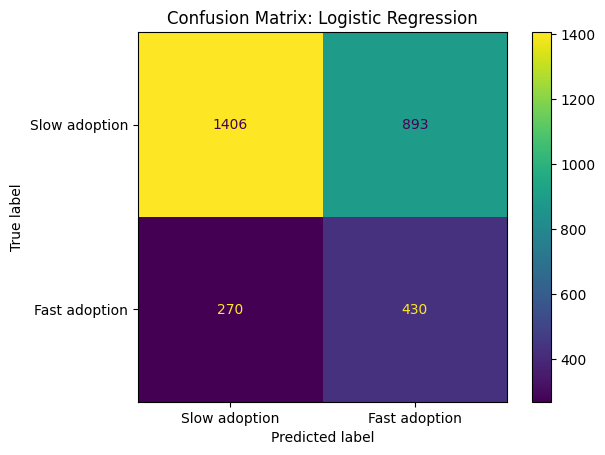

In [44]:
# We already computed y_pred for the weighted logistic regression model above.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Slow adoption", "Fast adoption"],
)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

To read the matrix, match each cell to a term. Remember that our positive class is `Fast adoption`:

- **Top left**: true negatives. Slow-adoption pets correctly predicted as slow.
- **Bottom right**: true positives. Fast-adoption pets correctly predicted as fast.
- **Bottom left**: false negatives. Fast-adoption pets the model missed.
- **Top right**: false positives. Slow-adoption pets incorrectly flagged as fast.

Use these counts to answer the discussion questions below. As you do, think about how the balance between false negatives and false positives connects to the recall and precision values you computed earlier.

<details>
<summary><b>Discussion questions</b> (optional — click to expand)</summary>

1. How many fast-adoption pets did the model correctly identify?
2. How many fast-adoption pets did the model miss?
3. How many slow-adoption pets were incorrectly predicted as fast adoption?
4. If a shelter wants to identify as many truly fast-adoption pets as possible, which metric matters most?
5. If a shelter wants its fast-adoption predictions to be highly reliable, which metric matters most?

</details>